### Integral Timescale and Velocity Uncertainty 

The main idea behind the integral timescale is to determine the effective degrees of freedom on the velocity data. Velocity data is inherently dominated by low frequency motion which leads to every sample not being fully indepenent of each other. 

Goal is to get confidence interval / uncertainty estimate for the mean velocity of a timeseries 


Analysis Steps: 

- Determine the integral timescale via autocorrelation 

- Estimate the effective degrees of freedom (N* = N delta T / integral timescale )

Functions to use: 

- integral_timescale_trapezoidal (follows definition of integral timescale in Emery and Thomson)
- standard_error_saunders (follows standard error estimate from Saunders (1987))

It's ok to just report the standard error as the error estimate on the mean velocity. Should try to do this for smaller timescales (i.e. monthly)

In [41]:
### imports
import numpy as np
import matplotlib.pyplot as plt 
import scipy 
import xarray as xr  
from TNB_tools import Integral_Timescale as its
import TNB_tools.tides.tidal_decomposition as tides

In [2]:
# load in data - DELL 
vel = xr.open_dataset("//thepenguin/penguin2/Data/TNB/mooring/LDEO/2018_19 Araon Cruise (ANA09B) - NIWAMooringRetrieval/Data/TNBD/working/tnbd_2018_vel_bot_1093.nc") 


In [3]:
its.check_gaps(vel)

Time series length: 28610 points
Median sampling interval: 900.0 s
u: 0 NaNs (0.00%)
v: 0 NaNs (0.00%)


{'n_points': 28610,
 'dt_median_s': np.float64(900.0),
 'n_irregular_steps': 4,
 'irregular_step_indices': array([28416, 28465, 28514, 28563]),
 'nan_counts': {'u': 0, 'v': 0}}

In [4]:
# cropping dataset in December 2018 to avoid weird timestamps 
vel = vel.sel(time=slice('2018-03','2018-12'))

In [5]:
its.check_gaps(vel)

Time series length: 28320 points
Median sampling interval: 900.0 s
Time sampling is regular.
u: 0 NaNs (0.00%)
v: 0 NaNs (0.00%)


{'n_points': 28320,
 'dt_median_s': np.float64(900.0),
 'n_irregular_steps': 0,
 'irregular_step_indices': array([], dtype=int64),
 'nan_counts': {'u': 0, 'v': 0}}

In [6]:
rho = its.autocorrelation(vel.u)

In [7]:
rho

array([ 1.00000000e+00,  9.67540360e-01,  9.60927276e-01, ...,
       -8.73928053e-06, -7.82812454e-06, -4.33584780e-06], shape=(28320,))

In [8]:
vel.u

<xarray.DataArray 'u' (time: 28320)> Size: 227kB
array([-4.525864, -5.741761, -5.112662, ..., -0.963701, -0.748781, -0.135978],
      shape=(28320,))
Coordinates:
  * time     (time) datetime64[ns] 227kB 2018-03-12 ... 2018-12-31T23:45:00
    lat      float64 8B ...
    lon      float64 8B ...
    z        int64 8B ...
Attributes:
    long_name:  Eastward Velocity
    units:      cm/s

In [9]:
dt_seconds = 900

In [20]:
nlags = int(70 * 86400 / dt_seconds)  # 10 days, in samples
rho = its.autocorrelation(vel.u, nlags=nlags)

In [21]:
dt_seconds = 900.0
lags_samples = np.arange(len(rho))
lags_hours = lags_samples * dt_seconds / 3600
lags_days = lags_samples * dt_seconds / 86400

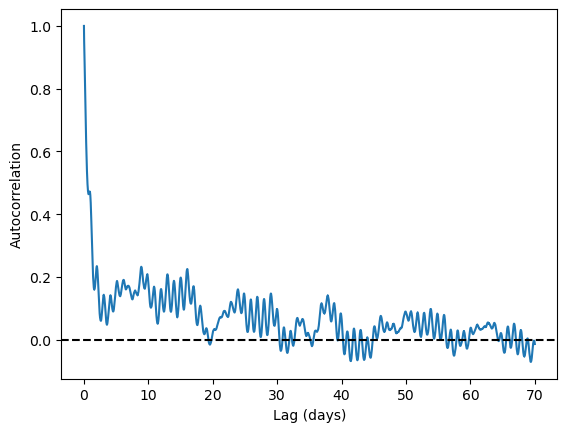

In [22]:
plt.plot(lags_days,rho)
plt.xlabel('Lag (days)')
plt.ylabel('Autocorrelation')
plt.axhline(y=0,color='k',ls='--')

In [23]:
T_int, k_star = its.integral_timescale(rho,dt_seconds)

In [26]:
T_l, zero_crossing = its.integral_timescale_trapezoidal(rho,dt_seconds)

In [28]:
T_l / 86400

np.float64(3.142883625835682)

In [ ]:
T_int

In [29]:
T_int / 86400 / 2

np.float64(3.1428850804092843)

In [30]:
k_star * dt_seconds / 86400

np.float64(19.333333333333332)

In [31]:
zero_crossing * dt_seconds / 86400

np.float64(19.333333333333332)

In [34]:
len(vel.u)

28320

In [39]:
# standard error
e = its.standard_error_saunders(sigma=np.std(vel.u),T_L=T_l,T_record=(len(vel.u.sel(time=slice('2018-04-01','2018-04-30')))*dt_seconds))

In [40]:
e

<xarray.DataArray 'u' ()> Size: 8B
array(2.47641534)
Coordinates:
    lat      float64 8B ...
    lon      float64 8B ...
    z        int64 8B ...
Attributes:
    long_name:  Eastward Velocity
    units:      cm/s

In [38]:
len(vel.u.sel(time=slice('2018-04-01','2018-04-30')))

2880

In [16]:
effective_dof = its.effective_dof(N=len(vel.u), dt=dt_seconds,T_int=T_int)

In [17]:
effective_dof

np.float64(46.93140099821649)

In [18]:
nlags = int(70 * 86400 / dt_seconds)  # search within 70 days
results = {v: its.analyze_component(vel, v, dt_seconds, nlags=nlags) for v in ("u", "v")}


--- u ---
Integral timescale: 543090.5 s (150.86 hr), zero crossing at lag 1856
N = 28320, N* = 46.9
Mean u = -1.2247, 95% CI = (-2.8144, 0.3650)

--- v ---
Integral timescale: 277394.9 s (77.05 hr), zero crossing at lag 704
N = 28320, N* = 91.9
Mean v = -1.6651, 95% CI = (-2.8635, -0.4667)


In [19]:
its.compare_confidence_intervals(vel['u'].values, dt_seconds)

T_int (two-sided) = 543090.5, T_L (one-sided) = 271545.3
N* = 46.9
SE (ours, N*)       = 0.78973   -> 95% CI (np.float64(-2.8143900109954574), np.float64(0.365042593395172))
SE (Saunders, T_L)  = 0.78973   -> 95% CI (np.float64(-2.7725240412560894), np.float64(0.323176623655804))
(SE values should match closely -- t vs. z multiplier is the main remaining difference, and matters more when N* is small)


{'mean': np.float64(-1.2246737088001427),
 'T_int': np.float64(543090.5418947244),
 'T_L': np.float64(271545.2709473622),
 'N_star': np.float64(46.93140099821649),
 'se_ours': np.float64(0.7897340689243235),
 'ci_ours': (np.float64(-2.8143900109954574), np.float64(0.365042593395172)),
 'se_saunders': np.float64(0.7897340689243235),
 'ci_saunders': (np.float64(-2.7725240412560894),
  np.float64(0.323176623655804))}

In [29]:
np.mean(vel.u)

<xarray.DataArray 'u' ()> Size: 8B
array(-1.22467371)
Coordinates:
    lat      float64 8B ...
    lon      float64 8B ...
    z        int64 8B ...
Attributes:
    long_name:  Eastward Velocity
    units:      cm/s

In [20]:
# calculating / verifying on my own 
N = len(vel.u)
sigma = np.std(vel.u)

In [21]:
N

28320

In [22]:
e_squared = (2*(T_int/2)*sigma**2)/(N*dt_seconds)

In [23]:
e_squared

<xarray.DataArray 'u' ()> Size: 8B
array(0.62365788)
Coordinates:
    lat      float64 8B ...
    lon      float64 8B ...
    z        int64 8B ...
Attributes:
    long_name:  Eastward Velocity
    units:      cm/s

In [24]:
np.sqrt(e_squared)

<xarray.DataArray 'u' ()> Size: 8B
array(0.78972013)
Coordinates:
    lat      float64 8B ...
    lon      float64 8B ...
    z        int64 8B ...
Attributes:
    long_name:  Eastward Velocity
    units:      cm/s

In [27]:
its.compare_integral_timescales(vel['u'].values, dt_seconds)

T_int (ours, two-sided, rectangle)     = 543090.5, k_star=1856
T_L   (= T_int/2, one-sided)            = 271545.3
T_ET  (E&T, one-sided, trapezoidal)     = 271545.1, k_star=1856
(T_L and T_ET should be close -- remaining gap is rectangle vs. trapezoid weighting of the endpoint at the zero crossing)


{'T_int': np.float64(543090.5418947244),
 'T_L': np.float64(271545.2709473622),
 'T_ET': np.float64(271545.1452722029),
 'k_star_rect': np.int64(1856),
 'k_star_trap': np.int64(1856)}

### Integral timescale on low-passed filtered data 

In [43]:
lowpass_ds, highpass_ds = tides.decompose_tidal_dataset(
    vel, var_names=["u", "v"], window_days=1, sampling_hours=0.25
)

In [44]:
lowpass_ds

<xarray.Dataset> Size: 680kB
Dimensions:  (time: 28320)
Coordinates:
  * time     (time) datetime64[ns] 227kB 2018-03-12 ... 2018-12-31T23:45:00
    lat      float64 8B -75.01
    lon      float64 8B 165.6
    z        int64 8B 1093
Data variables:
    u        (time) float64 227kB nan nan nan nan nan ... nan nan nan nan nan
    v        (time) float64 227kB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    decomposition:  low-pass via cosine window, window_days=1, sampling_hours...

In [45]:
# check data 
its.check_gaps(lowpass_ds.u)

Time series length: 28320 points
Median sampling interval: 900.0 s
Time sampling is regular.


{'n_points': 28320,
 'dt_median_s': np.float64(900.0),
 'n_irregular_steps': 0,
 'irregular_step_indices': array([], dtype=int64),
 'nan_counts': {}}

In [51]:
nan_mask = lowpass_ds["u"].isnull()
print(nan_mask.sum().item(), "total NaNs")
print(lowpass_ds["u"].time.where(nan_mask, drop=True).values)  # timestamps of NaNs

96 total NaNs
['2018-03-12T00:00:00.000000000' '2018-03-12T00:15:00.000000000'
 '2018-03-12T00:30:00.000000000' '2018-03-12T00:45:00.000000000'
 '2018-03-12T01:00:00.000000000' '2018-03-12T01:15:00.000000000'
 '2018-03-12T01:30:00.000000000' '2018-03-12T01:45:00.000000000'
 '2018-03-12T02:00:00.000000000' '2018-03-12T02:15:00.000000000'
 '2018-03-12T02:30:00.000000000' '2018-03-12T02:45:00.000000000'
 '2018-03-12T03:00:00.000000000' '2018-03-12T03:15:00.000000000'
 '2018-03-12T03:30:00.000000000' '2018-03-12T03:45:00.000000000'
 '2018-03-12T04:00:00.000000000' '2018-03-12T04:15:00.000000000'
 '2018-03-12T04:30:00.000000000' '2018-03-12T04:45:00.000000000'
 '2018-03-12T05:00:00.000000000' '2018-03-12T05:15:00.000000000'
 '2018-03-12T05:30:00.000000000' '2018-03-12T05:45:00.000000000'
 '2018-03-12T06:00:00.000000000' '2018-03-12T06:15:00.000000000'
 '2018-03-12T06:30:00.000000000' '2018-03-12T06:45:00.000000000'
 '2018-03-12T07:00:00.000000000' '2018-03-12T07:15:00.000000000'
 '2018-03-1

In [52]:
lowpass_clean = lowpass_ds["u"].dropna(dim="time")

In [53]:
lowpass_clean

<xarray.DataArray 'u' (time: 28224)> Size: 226kB
array([ 0.51721116,  0.55367866,  0.586614  , ..., -0.95388282,
       -0.95726911, -0.95800547], shape=(28224,))
Coordinates:
  * time     (time) datetime64[ns] 226kB 2018-03-12T12:00:00 ... 2018-12-31T1...
    lat      float64 8B -75.01
    lon      float64 8B 165.6
    z        int64 8B 1093
Attributes:
    long_name:  Eastward Velocity
    units:      cm/s
    filter:     cosine low-pass, window=97 samples

In [46]:
dt_seconds = 900

In [54]:
nlags = int(70 * 86400 / dt_seconds)  # 10 days, in samples
rho = its.autocorrelation(lowpass_clean, nlags=nlags)

In [55]:
dt_seconds = 900.0
lags_samples = np.arange(len(rho))
lags_hours = lags_samples * dt_seconds / 3600
lags_days = lags_samples * dt_seconds / 86400

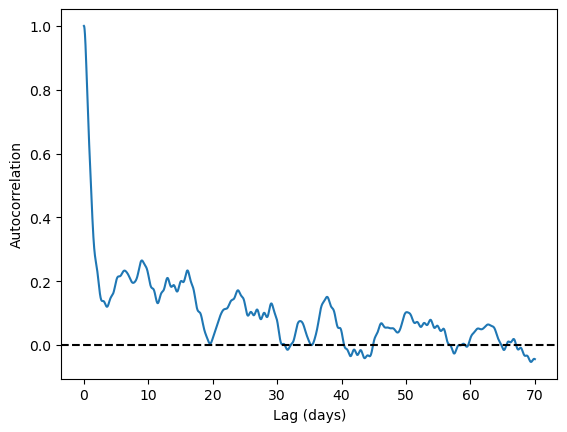

In [56]:
plt.plot(lags_days,rho)
plt.xlabel('Lag (days)')
plt.ylabel('Autocorrelation')
plt.axhline(y=0,color='k',ls='--')

In [57]:
T_l, zero_crossing = its.integral_timescale_trapezoidal(rho,dt_seconds)

In [58]:
# standard error
e = its.standard_error_saunders(sigma=np.std(lowpass_clean),T_L=T_l,T_record=(len(lowpass_clean)*dt_seconds))

In [59]:
e

<xarray.DataArray 'u' ()> Size: 8B
array(0.89025267)
Coordinates:
    lat      float64 8B -75.01
    lon      float64 8B 165.6
    z        int64 8B 1093
Attributes:
    long_name:  Eastward Velocity
    units:      cm/s
    filter:     cosine low-pass, window=97 samples

In [61]:
T_l / 86400

np.float64(5.357108798501014)

### progressive vector diagram 

In [67]:
import TNB_tools.pvd_tools as pvd

In [69]:
x,y = pvd.compute_pvd(vel.u/100,vel.v/100,dt=900)

<Axes: title={'center': 'Progressive Vector Diagram'}, xlabel='Eastward displacement (km)', ylabel='Northward displacement (km)'>

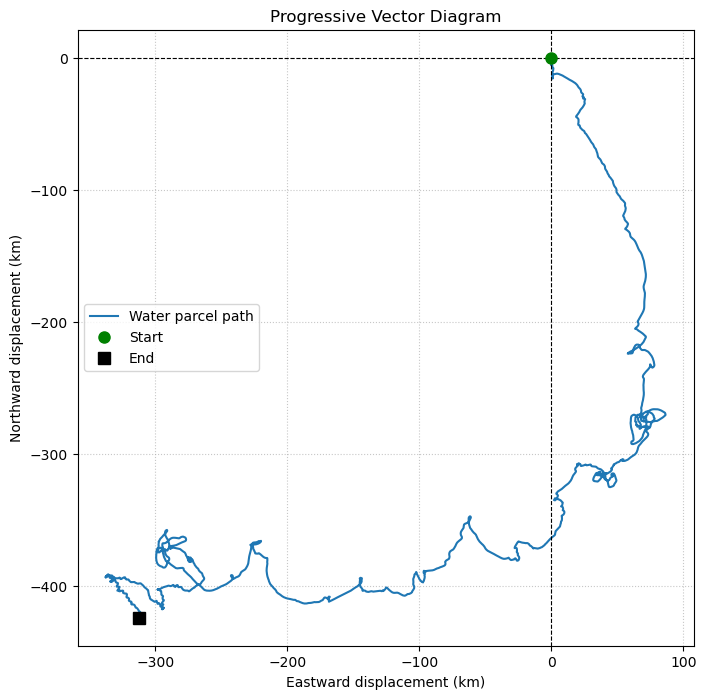

In [70]:
pvd.plot_pvd(x,y)

In [72]:
import pandas as pd

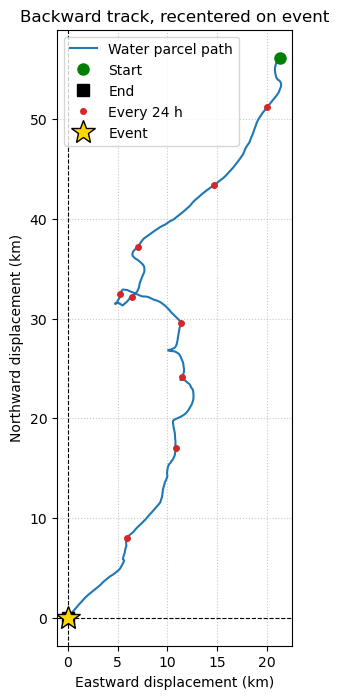

In [73]:
# x, y = compute_pvd(u_ms, v_ms, time=time, distance_units="km")
event_time = pd.Timestamp("2018-07-25T00:00")
event_idx = int(np.argmin(np.abs(pd.to_datetime(vel.time) - event_time)))
x_c, y_c = pvd.recenter_pvd(x, y, event_idx)
look_back = slice(max(0, event_idx - 960), event_idx + 1)  # ~10 days @ 900s
pvd.plot_pvd(x_c[look_back], y_c[look_back], time=vel.time[look_back],
            event_index=-1, event_label="Event",
            title="Backward track, recentered on event")
plt.show()

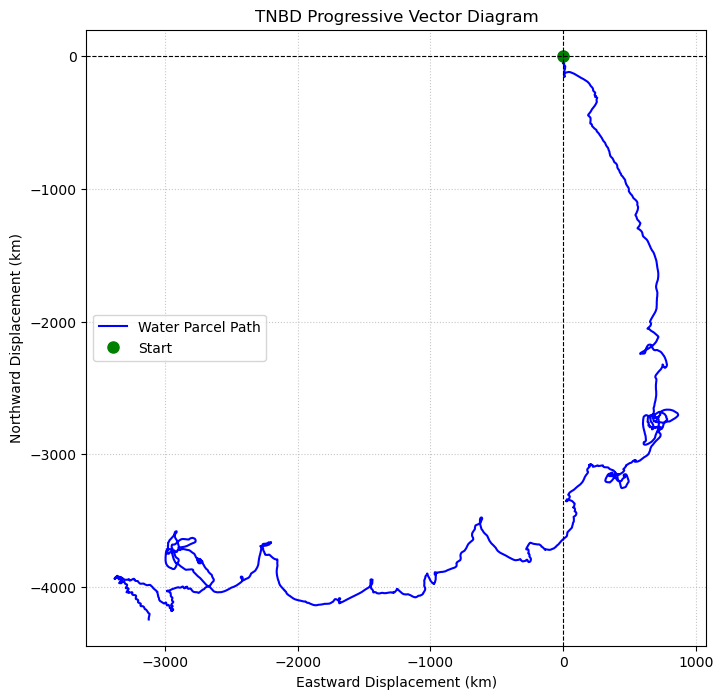

In [62]:
# 2. Convert velocity to displacement (distance = velocity * time)
hours = len(vel.u)*900 / 3600
dt = 900 # seconds
dx = vel.u /10000 * dt
dy = vel.v / 10000* dt

# 3. Calculate the cumulative sum to get the total path (x, y)
x_path = np.cumsum(dx)
y_path = np.cumsum(dy)

# 4. Plot the Progressive Vector Diagram
plt.figure(figsize=(8, 8))
plt.plot(x_path, y_path, color='blue', linewidth=1.5, label='Water Parcel Path')

# Mark the starting point
plt.plot(x_path[0], y_path[0], 'go', markersize=8, label='Start')

# # Add daily markers (24 hours * 3600 seconds = 86400 seconds)
# day_indices = np.arange(0, hours, 24)
# plt.plot(x_path[day_indices], y_path[day_indices], 'ro', markersize=4, label='Daily Mark')

# Formatting the plot
plt.title('TNBD Progressive Vector Diagram')
plt.xlabel('Eastward Displacement (km)')
plt.ylabel('Northward Displacement (km)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.axis('equal') # Ensures 1 meter East = 1 meter North visually
plt.show()

Text(0.5, 0, 'Time')

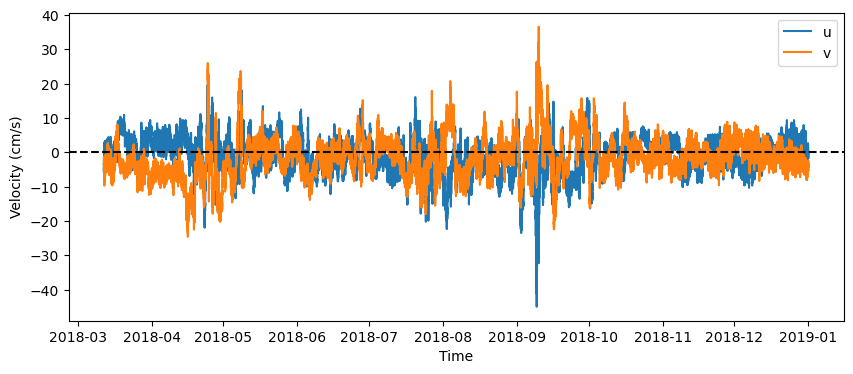

In [26]:
fig = plt.figure(figsize=(10,4))
plt.plot(vel.u.time,vel.u,label='u')
plt.plot(vel.v.time,vel.v,label='v')
plt.legend()
plt.axhline(y=0,color='k',ls='--')
plt.ylabel('Velocity (cm/s)')
plt.xlabel('Time')